In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("tugas2.csv")

In [3]:
data.shape

(500, 9)

In [4]:
data.columns

Index(['id_customer', 'nama_customer', 'usia', 'gender', 'kota',
       'kategori_produk', 'produk', 'nilai_transaksi', 'tanggal_beli'],
      dtype='str')

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_customer      500 non-null    int64  
 1   nama_customer    500 non-null    str    
 2   usia             447 non-null    str    
 3   gender           500 non-null    str    
 4   kota             444 non-null    str    
 5   kategori_produk  500 non-null    str    
 6   produk           500 non-null    str    
 7   nilai_transaksi  432 non-null    float64
 8   tanggal_beli     500 non-null    str    
dtypes: float64(1), int64(1), str(7)
memory usage: 35.3 KB


In [6]:
data.describe(include="all")

,id_customer,nama_customer,usia,gender,kota,kategori_produk,produk,nilai_transaksi,tanggal_beli
count,500.000000,500,447,500,444,500,500,4.320000e+02,500
unique,NaN,15,9,2,8,3,16,NaN,83
top,NaN,Tina,40,P,Jakarta,Kosmetik,Serum,NaN,2024/02/15
freq,NaN,44,60,262,73,180,53,NaN,14
mean,2248.386000,NaN,NaN,NaN,NaN,NaN,NaN,1.194352e+07,NaN
std,144.469734,NaN,NaN,NaN,NaN,NaN,NaN,2.852142e+07,NaN
min,2002.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.500000e+05,NaN
25%,2120.750000,NaN,NaN,NaN,NaN,NaN,NaN,3.000000e+05,NaN
50%,2247.500000,NaN,NaN,NaN,NaN,NaN,NaN,7.500000e+05,NaN
75%,2373.250000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000e+06,NaN


In [7]:
data.select_dtypes(include=["object"]).columns

C:\Users\IIK\AppData\Local\Temp\ipykernel_16348\508198371.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.select_dtypes(include=["object"]).columns


Index(['nama_customer', 'usia', 'gender', 'kota', 'kategori_produk', 'produk',
       'tanggal_beli'],
      dtype='str')

In [8]:
data.groupby("produk")["nilai_transaksi"].mean()

produk
Bedak         1.015000e+07
Dress         1.070000e+07
Headset       1.597321e+07
Jaket         8.880952e+06
Kaos          1.181842e+07
Keyboard      5.425000e+06
Laptop        8.420455e+06
Lipstik       1.353625e+07
Monitor       1.288571e+07
Mouse         1.221591e+07
Power Bank    1.927391e+07
Sepatu        6.885714e+06
Serum         1.686190e+07
Skincare      7.176250e+06
Smartphone    1.990000e+07
Tas           1.128438e+07
Name: nilai_transaksi, dtype: float64

In [9]:
data.groupby("gender")["nilai_transaksi"].mean()

gender
L    1.297748e+07
P    1.103543e+07
Name: nilai_transaksi, dtype: float64

In [10]:
data.groupby("gender")["nilai_transaksi"].value_counts()

gender  nilai_transaksi
L       1200000.0          37
        2000000.0          33
        750000.0           29
        85000000.0         29
        500000.0           27
        300000.0           25
        150000.0           22
P       750000.0           41
        500000.0           36
        300000.0           35
        1200000.0          32
        150000.0           30
        2000000.0          28
        85000000.0         28
Name: count, dtype: int64

In [11]:
data["gender"].value_counts()

gender
P    262
L    238
Name: count, dtype: int64

In [12]:
data.isnull().sum()

id_customer         0
nama_customer       0
usia               53
gender              0
kota               56
kategori_produk     0
produk              0
nilai_transaksi    68
tanggal_beli        0
dtype: int64

In [41]:
data["usia"] = data["usia"].fillna(data["usia"].median())
data["kota"] = data["kota"].fillna(data["kota"].mode()[0])
data["nilai_transaksi"] = data["nilai_transaksi"].fillna(
    data["nilai_transaksi"].median()
)
data

,id_customer,nama_customer,usia,gender,kota,kategori_produk,produk,nilai_transaksi,tanggal_beli,kategori_usia,gender_enc,kategori_produk_enc,kota_enc,nama_customer_enc
0,2090,Doni,22.0,P,Bogor,Elektronik,Laptop,150000.0,13-02-2024,Remaja,1,0,2,3
1,2002,Tina,18.0,L,Surabaya,Fashion,Sepatu,2000000.0,08/02/2024,Remaja,0,1,5,13
2,2003,Irwan,45.0,L,Bandung,Elektronik,Laptop,150000.0,2024/02/11,Dewasa,0,0,0,6
3,2004,Irwan,18.0,L,Surabaya,Elektronik,Smartphone,150000.0,2024/02/10,Remaja,0,0,5,6
4,2005,Sari,35.0,P,Jakarta,Kosmetik,Serum,2000000.0,2024/02/17,Dewasa,1,2,4,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2496,Nia,30.0,P,Jakarta,Elektronik,Mouse,150000.0,09/02/2024,Dewasa,1,0,4,8
496,2497,Bayu,18.0,L,Jakarta,Kosmetik,Lipstik,300000.0,2024/02/16,Remaja,0,2,4,2
497,2498,Agus,40.0,P,Bogor,Fashion,Kaos,750000.0,21-02-2024,Dewasa,1,1,2,1
498,2499,Hendra,150.0,L,Bogor,Elektronik,Smartphone,750000.0,11-02-2024,Lansia,0,0,2,5


In [14]:
def kelompokkan_usia(x):
    import pandas as pd

    if pd.isna(x):
        return "Tidak Diketahui"
    if x <= 17:
        return "Anak-anak"
    elif x <= 25:
        return "Remaja"
    elif x <= 55:
        return "Dewasa"
    else:
        return "Lansia"

Konversi umur dari string ke int 

In [15]:
data["usia"] = pd.to_numeric(data["usia"], errors="coerce")

In [16]:
data["kategori_usia"] = data["usia"].apply(kelompokkan_usia)
data["kategori_usia"].value_counts()

kategori_usia
Dewasa             199
Remaja             153
Tidak Diketahui    104
Lansia              44
Name: count, dtype: int64

In [17]:
data.head()

,id_customer,nama_customer,usia,gender,kota,kategori_produk,produk,nilai_transaksi,tanggal_beli,kategori_usia
0,2090,Doni,22.0,P,Bogor,Elektronik,Laptop,150000.0,13-02-2024,Remaja
1,2002,Tina,18.0,L,Surabaya,Fashion,Sepatu,2000000.0,08/02/2024,Remaja
2,2003,Irwan,45.0,L,bandung,Elektronik,Laptop,150000.0,2024/02/11,Dewasa
3,2004,Irwan,18.0,L,Surabaya,Elektronik,Smartphone,150000.0,2024/02/10,Remaja
4,2005,Sari,35.0,P,Jakarta,Kosmetik,Serum,2000000.0,2024/02/17,Dewasa


In [18]:
data["tanggal_beli"]
pd.to_datetime(data["tanggal_beli"], errors="coerce")

C:\Users\IIK\AppData\Local\Temp\ipykernel_16348\135684740.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  pd.to_datetime(data["tanggal_beli"], errors="coerce")


0     2024-02-13
1            NaT
2            NaT
3            NaT
4            NaT
         ...    
495          NaT
496          NaT
497   2024-02-21
498   2024-02-11
499          NaT
Name: tanggal_beli, Length: 500, dtype: datetime64[us]

In [19]:
data["tanggal_beli"].unique()

<StringArray>
['13-02-2024', '08/02/2024', '2024/02/11', '2024/02/10', '2024/02/17',
 '2024/02/18', '2024/02/03', '2024/02/15', '01-02-2024', '2024-02-02',
 '2024/02/09', '21/02/2024', '18-02-2024', '2024-02-15', '17-02-2024',
 '08-02-2024', '2024-02-13', '19/02/2024', '18/02/2024', '2024-02-11',
 '12/02/2024', '04-02-2024', '2024/02/19', '15-02-2024', '2024-02-04',
 '16/02/2024', '2024-02-19', '2024/02/06', '02-02-2024', '2024-02-17',
 '2024/02/21', '2024-02-08', '14-02-2024', '2024-02-10', '2024/02/05',
 '2024-02-05', '10-02-2024', '19-02-2024', '2024/02/08', '2024/02/04',
 '12-02-2024', '04/02/2024', '14/02/2024', '10/02/2024', '2024-02-06',
 '01/02/2024', '2024/02/20', '02/02/2024', '09-02-2024', '2024-02-12',
 '2024-02-20', '21-02-2024', '17/02/2024', '06/02/2024', '05-02-2024',
 '2024/02/16', '2024-02-16', '2024-02-03', '2024/02/14', '05/02/2024',
 '15/02/2024', '11/02/2024', '03/02/2024', '20/02/2024', '2024/02/12',
 '2024/02/07', '06-02-2024', '09/02/2024', '2024-02-07', '03-02

In [20]:
data["kota"] = data["kota"].str.title()

Penjelasan:
str.title() → menyeragamkan format teks
Mengubah jakarta, JAKARTA menjadi Jakarta

In [21]:
data["gender"] = data["gender"].replace("", "Tidak Diketahui")

kondisi jika ada kolom kosong

In [22]:
data.duplicated().sum()

np.int64(0)

Menghapus jika ada data duplikasi

In [23]:
data = data.drop_duplicates()

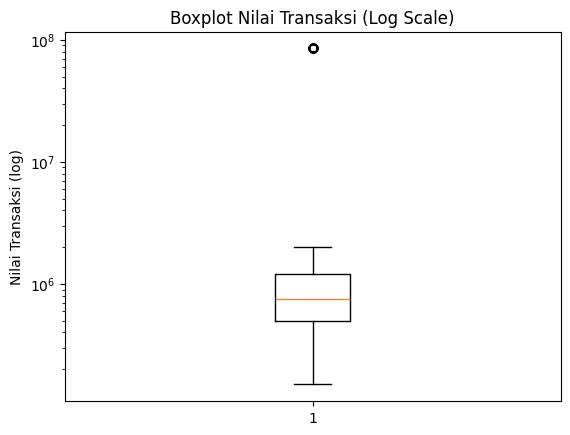

In [24]:
plt.boxplot(data["nilai_transaksi"].dropna())
plt.yscale("log")
plt.title("Boxplot Nilai Transaksi (Log Scale)")
plt.ylabel("Nilai Transaksi (log)")
plt.show()

In [25]:
data["nilai_transaksi"].describe()

count    5.000000e+02
mean     1.042120e+07
std      2.678376e+07
min      1.500000e+05
25%      5.000000e+05
50%      7.500000e+05
75%      1.200000e+06
max      8.500000e+07
Name: nilai_transaksi, dtype: float64

Penjelasan:

- Q1 → kuartil bawah (25%)
- Q3 → kuartil atas (75%)
- IQR → rentang data tengah
- Q3 + 1.5 * IQR → batas atas nilai wajar
- Nilai di atas batas tersebut dibatasi (bukan dihapus)

In [26]:
Q1 = data["nilai_transaksi"].quantile(0.25)
Q3 = data["nilai_transaksi"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
data.loc[data["nilai_transaksi"] > upper_bound, "nilai_transaksi"] = upper_bound

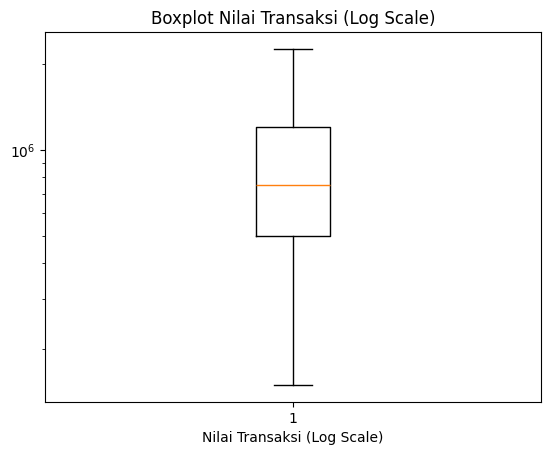

In [27]:
plt.boxplot(data["nilai_transaksi"].dropna())
plt.yscale("log")
plt.title("Boxplot Nilai Transaksi (Log Scale)")
plt.xlabel("Nilai Transaksi (Log Scale)")
plt.show()

Identifikasi atribut kategorikal

Penjelasan kode:
- select_dtypes(include="object") -> memilih kolom bertipe teks
- columns -> menampilkan nama kolom

In [28]:
data.select_dtypes(include="object").columns

C:\Users\IIK\AppData\Local\Temp\ipykernel_16348\1271515388.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.select_dtypes(include="object").columns


Index(['nama_customer', 'gender', 'kota', 'kategori_produk', 'produk',
       'tanggal_beli', 'kategori_usia'],
      dtype='str')

Import library

Penjelasan:
- Mengimpor kelas LabelEncoder dari scikit-learn
- Digunakan untuk mengubah kategori → angka

In [29]:
from sklearn.preprocessing import LabelEncoder

Encoding

Penjelasan baris per baris:
- LabelEncoder() → membuat objek encoder
- fit_transform():
    - fit → mempelajari kategori unik
    - transform → mengonversi kategori menjadi angka
- Hasil disimpan di kolom baru jenis_kelamin_enc

In [30]:
# Encoding jenis_kelamin
le_jenis_kelamin = LabelEncoder()
data["gender_enc"] = le_jenis_kelamin.fit_transform(data["gender"])

# Encoding jenis_produk
le_jenis_produk = LabelEncoder()
data["kategori_produk_enc"] = le_jenis_produk.fit_transform(data["kategori_produk"])

# Encoding kota
le_kota = LabelEncoder()
data["kota_enc"] = le_kota.fit_transform(data["kota"])

# Encoding nama_produk
le_nama_produk = LabelEncoder()
data["nama_customer_enc"] = le_nama_produk.fit_transform(data["nama_customer"])

Identifikasi Atribut Numerik yang Akan Dinormalisasi

Normalisasi digunakan untuk menyeragamkan skala data numerik, karena pada dataset Anda terdapat perbedaan skala
yang signifikan, misalnya:
- umur → puluhan
- total_transaksi → jutaan
- hasil encoding → bilangan kecil (0, 1, 2, ...)

Tanpa normalisasi:
- Algoritma berbasis jarak (K-Means, KNN) akan lebih dipengaruhi oleh fitur berskala besar
- Fitur berskala kecil menjadi tidak berpengaruh

In [31]:
data.select_dtypes(include=["int64", "float64"]).columns

Index(['id_customer', 'usia', 'nilai_transaksi', 'gender_enc',
       'kategori_produk_enc', 'kota_enc', 'nama_customer_enc'],
      dtype='str')

Menentukan kolom yang akan dinormalisasikan

In [32]:
kolom_numerik = [
    "usia",
    "nilai_transaksi",
    "gender_enc",
    "kategori_produk_enc",
    "kota_enc",
    "nama_customer_enc",
]

In [33]:
from sklearn.preprocessing import MinMaxScaler

In [34]:
# encoding
encoder = LabelEncoder()

data["kategori_produk_enc"] = encoder.fit_transform(data["kategori_produk"])
data["kota_enc"] = encoder.fit_transform(data["kota"])
data["nama_customer_enc"] = encoder.fit_transform(data["nama_customer"])

In [35]:
# normalize

kolom_numerik = [
    "usia",
    "nilai_transaksi",
    "kategori_produk_enc",
    "kota_enc",
    "nama_customer_enc",
]

scaler = MinMaxScaler()
data_normalized = data.copy()
data_normalized[kolom_numerik] = scaler.fit_transform(data[kolom_numerik])

In [36]:
data_normalized[kolom_numerik].describe()

,usia,nilai_transaksi,kategori_produk_enc,kota_enc,nama_customer_enc
count,396.000000,500.000000,500.000000,500.000000,500.000000
mean,0.195458,0.398905,0.510000,0.456333,0.536000
std,0.292158,0.333048,0.418629,0.334723,0.311317
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.030303,0.166667,0.000000,0.166667,0.285714
50%,0.090909,0.285714,0.500000,0.500000,0.571429
75%,0.166667,0.500000,1.000000,0.666667,0.785714
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [37]:
data[["usia", "nilai_transaksi"]].head()

,usia,nilai_transaksi
0,22.0,150000.0
1,18.0,2000000.0
2,45.0,150000.0
3,18.0,150000.0
4,35.0,2000000.0


In [38]:
data_normalized[["usia", "nilai_transaksi"]].head()

,usia,nilai_transaksi
0,0.030303,0.000000
1,0.000000,0.880952
2,0.204545,0.000000
3,0.000000,0.000000
4,0.128788,0.880952


In [39]:
data_normalized.head(20)

,id_customer,nama_customer,usia,gender,kota,kategori_produk,produk,nilai_transaksi,tanggal_beli,kategori_usia,gender_enc,kategori_produk_enc,kota_enc,nama_customer_enc
0,2090,Doni,0.030303,P,Bogor,Elektronik,Laptop,0.000000,13-02-2024,Remaja,1,0.0,0.333333,0.214286
1,2002,Tina,0.000000,L,Surabaya,Fashion,Sepatu,0.880952,08/02/2024,Remaja,0,0.5,0.833333,0.928571
2,2003,Irwan,0.204545,L,Bandung,Elektronik,Laptop,0.000000,2024/02/11,Dewasa,0,0.0,0.000000,0.428571
3,2004,Irwan,0.000000,L,Surabaya,Elektronik,Smartphone,0.000000,2024/02/10,Remaja,0,0.0,0.833333,0.428571
4,2005,Sari,0.128788,P,Jakarta,Kosmetik,Serum,0.880952,2024/02/17,Dewasa,1,1.0,0.666667,0.785714
5,2006,Tina,1.000000,P,Jakarta,Elektronik,Headset,1.000000,2024/02/18,Lansia,1,0.0,0.666667,0.928571
6,2007,Hendra,0.204545,P,NaN,Kosmetik,Lipstik,0.166667,2024/02/03,Dewasa,1,1.0,1.000000,0.357143
7,2008,Doni,0.053030,P,Bekasi,Kosmetik,Bedak,0.071429,2024/02/15,Remaja,1,1.0,0.166667,0.214286
8,2009,Agus,0.166667,L,Depok,Kosmetik,Lipstik,0.880952,01-02-2024,Dewasa,0,1.0,0.500000,0.071429
9,2010,Fahmi,NaN,L,Bogor,Elektronik,Headset,0.285714,2024/02/18,Tidak Diketahui,0,0.0,0.333333,0.285714


In [40]:
data.head(20)

,id_customer,nama_customer,usia,gender,kota,kategori_produk,produk,nilai_transaksi,tanggal_beli,kategori_usia,gender_enc,kategori_produk_enc,kota_enc,nama_customer_enc
0,2090,Doni,22.0,P,Bogor,Elektronik,Laptop,150000.0,13-02-2024,Remaja,1,0,2,3
1,2002,Tina,18.0,L,Surabaya,Fashion,Sepatu,2000000.0,08/02/2024,Remaja,0,1,5,13
2,2003,Irwan,45.0,L,Bandung,Elektronik,Laptop,150000.0,2024/02/11,Dewasa,0,0,0,6
3,2004,Irwan,18.0,L,Surabaya,Elektronik,Smartphone,150000.0,2024/02/10,Remaja,0,0,5,6
4,2005,Sari,35.0,P,Jakarta,Kosmetik,Serum,2000000.0,2024/02/17,Dewasa,1,2,4,11
5,2006,Tina,150.0,P,Jakarta,Elektronik,Headset,2250000.0,2024/02/18,Lansia,1,0,4,13
6,2007,Hendra,45.0,P,NaN,Kosmetik,Lipstik,500000.0,2024/02/03,Dewasa,1,2,6,5
7,2008,Doni,25.0,P,Bekasi,Kosmetik,Bedak,300000.0,2024/02/15,Remaja,1,2,1,3
8,2009,Agus,40.0,L,Depok,Kosmetik,Lipstik,2000000.0,01-02-2024,Dewasa,0,2,3,1
9,2010,Fahmi,NaN,L,Bogor,Elektronik,Headset,750000.0,2024/02/18,Tidak Diketahui,0,0,2,4
